## **XGBoost Notebook**

This notebook serves as a tutorial / testing ground where I can add new variables for testing on a small scale, before putting into my script. It's slightly different compared to the script, in which the script uses entire datasets for training, and then gets tested on unseen datasets, whereas this notebook takes 1 (sometimes more) datasets, and splits the sets randomly 80/20. This may be moved to the way the script works, as its easier to plot how well train vs test is, which is good for noticing overfitting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpls
import xgboost as xgb
import uproot
from lorentzboost import determine_boost
import awkward as ak 
import vector

Error in <TExMap::Add>: key 140310320323104 is not unique
Error in <TExMap::Add>: key 140310319731328 is not unique


In [2]:
input_files = [
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2276.eicrecon.edm4eic.root"
    #"/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2275.eicrecon.edm4eic.root",
    #"/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2274.eicrecon.edm4eic.root"
]

trees = [uproot.open(f)["events"] for f in input_files]

In [5]:
filter_name=[
    "ReconstructedParticles/ReconstructedParticles.*",
    "MCParticles/MCParticles.*",
    "EcalBarrelClusters/EcalBarrelClusters.*",
    "EcalEndcapPClusters/EcalEndcapPClusters.*",
    "EcalEndcapNClusters/EcalEndcapNClusters.*",
    "EcalBarrelClusterAssociations/EcalBarrelClusterAssociations.*",
    "EcalEndcapPClusterAssociations/EcalEndcapPClusterAssociations.*",
    "EcalEndcapNClusterAssociations/EcalEndcapNClusterAssociations.*",
    "ReconstructedParticleAssociations/ReconstructedParticleAssociations.*" 
]

events_list = [tree.arrays(filter_name=filter_name, library="ak") for tree in trees]
events = ak.concatenate(events_list, axis=0)

In [12]:
# defining variables

# mc classification
mc_pdg = events["MCParticles.PDG"]
mc_gen = events["MCParticles.generatorStatus"]


# track kinematics (raw from detector)
px_raw = events["ReconstructedParticles.momentum.x"]
py_raw = events["ReconstructedParticles.momentum.y"]
pz_raw = events["ReconstructedParticles.momentum.z"]
q = events["ReconstructedParticles.charge"]

# boost for crossing angle correction
xAngle = -0.025
cos_a = np.cos(xAngle)
sin_a = np.sin(xAngle)
# Corrected momentum: rotate (px, pz) by xAngle
px = px_raw * cos_a - pz_raw * sin_a
py = py_raw  # py unchanged
pz = px_raw * sin_a + pz_raw * cos_a

# cluster energies 
barrel_E = events["EcalBarrelClusters.energy"]
endcapP_E = events["EcalEndcapPClusters.energy"]
endcapN_E = events["EcalEndcapNClusters.energy"]

vector.register_awkward() # vector used instead of PxPyPzEVector for compatibility
reco_vec = vector.Array(ak.zip({   # zip takes the awkward arrays and makes a single structured array where each element   
    "px": px,                      # has a named field
    "py": py,
    "pz": pz,
    "energy": np.sqrt(px**2 + py**2 + pz**2)  # massless for now, won't even be used
}))

pt  = reco_vec.pt  # transverse momentum 
eta = reco_vec.eta # pseudorapidity
phi = reco_vec.phi # azimuthal angle
p   = reco_vec.rho # mom magnitude

# MC matching, same logic as my C++ cluster reconstruction code
# ReconstructedParticle and MC associations
reco_to_mc_rec = events["ReconstructedParticleAssociations.recID"]  # reco particle index
reco_to_mc_sim = events["ReconstructedParticleAssociations.simID"]  # MC particle index

# cluster and MC associations (recID is cluster index, simID is MC particle index)
barrel_clu_idx = events["EcalBarrelClusterAssociations.recID"]
barrel_mc_idx  = events["EcalBarrelClusterAssociations.simID"]   

# same for the endcaps
endcapP_clu_idx = events["EcalEndcapPClusterAssociations.recID"]
endcapP_mc_idx  = events["EcalEndcapPClusterAssociations.simID"]

endcapN_clu_idx = events["EcalEndcapNClusterAssociations.recID"]
endcapN_mc_idx  = events["EcalEndcapNClusterAssociations.simID"]

### **Boosting**

Here, the entire boost from lorentzboost.py isn't used. This is because its not useful here as $Q^{2}$, $x$ and $y$ aren't computed here. Instead, the beam angle crossing correction is applied and that's all for now. I assume the Bjorken values aren't good for discriminating as they're representative of the event rather than the scattered electron (i think), but will remember to ask.



In [13]:
# matching (mirror C++ logic: pick one cluster per reco track via MC)
def match_via_mc(reco_rec, reco_sim,
                 barrel_clu, barrel_mc, barrel_E,
                 endcapP_clu, endcapP_mc, endcapP_E,
                 endcapN_clu, endcapN_mc, endcapN_E, n_reco):
    barrel_E_out = [0.0] * n_reco # makes columns of zeroes that are as long as the number of reconstructed particles in each event
    endcapN_E_out = [0.0] * n_reco
    endcapP_E_out = [0.0] * n_reco

    mc_to_reco = {} # empty dictionary made
    for rec_idx, mc_idx in zip(reco_rec, reco_sim): # zip makes pairs of matching reco and mc indices, and loops through all events
        mc_to_reco[mc_idx] = rec_idx      # fills the dictionary with mc_idx as key and rec_idx as value

    # barrel first
    for clu_idx, mc_idx in zip(barrel_clu, barrel_mc): # matches cluster indices to mc indices, and loops through all events in cluster
        mc_idx = int(mc_idx) # ensures mc_idx is integer
        if mc_idx in mc_to_reco: # checks if mc index is in the dictionary keys
            reco_idx = mc_to_reco[mc_idx] # gets the corresponding reco index from the dictionary
            barrel_E_out[reco_idx] = float(barrel_E[clu_idx]) # assigns the cluster energy to the correct reco index in the output list

    # then endcapN
    for clu_idx, mc_idx in zip(endcapN_clu, endcapN_mc):
        mc_idx = int(mc_idx)
        if mc_idx in mc_to_reco:
            reco_idx = mc_to_reco[mc_idx]
            endcapN_E_out[reco_idx] = float(endcapN_E[clu_idx])

    # finally endcapP
    for clu_idx, mc_idx in zip(endcapP_clu, endcapP_mc):
        mc_idx = int(mc_idx)
        if mc_idx in mc_to_reco:
            reco_idx = mc_to_reco[mc_idx]
            endcapP_E_out[reco_idx] = float(endcapP_E[clu_idx])

    return barrel_E_out, endcapN_E_out, endcapP_E_out


### **Matching**

Code is meant to follow same workflow as that in the C++ code from sem1. Uses the MC particles as an intermediary to match reco particles and cluster energies.

In [14]:
# matches cluster to reco for each event
results = [
    match_via_mc(r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco)
    for r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco in zip(
        reco_to_mc_rec, reco_to_mc_sim,
        barrel_clu_idx, barrel_mc_idx, barrel_E,
        endcapP_clu_idx, endcapP_mc_idx, endcapP_E,
        endcapN_clu_idx, endcapN_mc_idx, endcapN_E,
        ak.num(px)
    )
]

barrel_E_per_reco = ak.Array([r[0] for r in results]) # gets barrel energies from each tuple, and converts back into awkward array
endcapN_E_per_reco = ak.Array([r[1] for r in results])
endcapP_E_per_reco = ak.Array([r[2] for r in results])

matched_calo_E = ak.where( # used ak.where instead of for loops as it's quicker for large arrays
    barrel_E_per_reco > 0,
    barrel_E_per_reco,
    ak.where(
        endcapN_E_per_reco > 0,
        endcapN_E_per_reco,
        ak.where(endcapP_E_per_reco > 0, endcapP_E_per_reco, 0.0)
    )
)
matched_E_over_p = ak.where(p > 0, matched_calo_E / p, 0.0)

In [15]:
def calculate_isolation(eta, phi, cluster_E, cone_size):
    isolation_E = []

    for event_eta, event_phi, event_E in zip(eta, phi, cluster_E):
        event_iso = []
        n_particles = len(event_eta)

        for i in range(n_particles):
            d_eta = event_eta - event_eta[i]
            d_phi = event_phi - event_phi[i]

            # Wrap d_phi into (-pi, pi)
            d_phi = ak.where(d_phi > np.pi, d_phi - (2 * np.pi), d_phi)
            d_phi = ak.where(d_phi < -np.pi, d_phi + (2 * np.pi), d_phi)

            dR = np.sqrt(d_eta**2 + d_phi**2)

            iso_mask = (dR < cone_size) & (dR > 0) # dR > 0 to skip itself
            iso_energy = ak.sum(event_E[iso_mask])

            event_iso.append(float(iso_energy))

        isolation_E.append(event_iso)

    return ak.Array(isolation_E)

In [16]:
isolation_E = calculate_isolation(eta, phi, matched_calo_E, cone_size=0.4)

isolation_frac = ak.where((matched_calo_E + isolation_E) > 0, matched_calo_E / (matched_calo_E + isolation_E), 0.0) # prevents invalid number warnings for division

/home/user321/projectxg/xgbenv/lib64/python3.13/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


### **Isolation**

Calculates isolation as the fraction of energy compared to the total energy. Meant to follow same flow as that from ElectronID code, also currently using $dR < 0.4$, as this is in ElectronID, must remember to test tweaking to see if this may affect the fitting.

In [17]:
def find_greatest_pt(pt_array):
    is_leading = []
    for event_pt in pt_array:
        if len(event_pt) == 0:
            is_leading.append([]) # for event with no particles, edge case to stop it breaking
        else:
            max_index = ak.argmax(event_pt) # finds index of max pt value for event
            event_flags = [i == max_index for i in range(len(event_pt))]
            is_leading.append(event_flags)
    return ak.Array(is_leading)

### **Greatest $p_{T}$**

The scattered electron typically has the greatest transverse momentum per event.

In [21]:
labels = []
for mc_ids, pdgs, gens in zip(reco_to_mc_sim, mc_pdg, mc_gen): # loops over events
    # find first final-state electron in this event
    target_mc = -1
    for idx, (pdg, gen) in enumerate(zip(pdgs, gens)):
        if abs(pdg) == 11 and gen == 1:
            target_mc = idx
            break
    # assign label 1 only to reco tracks matched to that electron
    lab = ak.Array([1 if int(mc_id) == target_mc and target_mc >= 0 else 0 for mc_id in mc_ids])
    labels.append(lab)

labels = ak.Array(labels)

# flatten features and labels together
E_over_p_feat = ak.flatten(matched_E_over_p)
iso_feat = ak.flatten(isolation_frac)
leading_pt_feat = ak.flatten(is_leading_pt)
charge = ak.flatten(q)
labs = ak.flatten(labels)

mask = ak.flatten(matched_calo_E) > 0 # filters for entries with a matched cluster
E_over_p_feat = E_over_p_feat[mask]
iso_feat = iso_feat[mask]
leading_pt_feat = leading_pt_feat[mask]
charge_feat = charge[mask]
labs = labs[mask]

X_df = pd.DataFrame({
    "E_over_p": ak.to_numpy(E_over_p_feat),
    "isolation_frac": ak.to_numpy(iso_feat),
    "is_leading_pt": ak.to_numpy(leading_pt_feat).astype(int), # astype(int) as its a True/ False before
    "charge" : ak.to_numpy(charge_feat)
})
y = ak.to_numpy(labs)

### **Compiling the features**

At this point all the features have been found. If new features are to be tested, they must be done before this code block, and their features must be inputted here. Mask used instead of filter, as filter gave issues when runniing. Mask just filters out events that don't have a matched calo energy. Charge is also used as a discriminating variable, as all scattered electrons have negative charge (duh).

In [22]:
# determining ratio of scattered electrons to background to inform scale_pos_weight
unique, counts = np.unique(y, return_counts=True)
n_background = counts[0]
n_signal = counts[1]
scale_pos_weight = n_background / n_signal
print(scale_pos_weight)


4.575688073394495


In [23]:
from sklearn.model_selection import train_test_split
X = np.asarray(X_df[["E_over_p", "isolation_frac", "is_leading_pt"]])
y = np.asarray(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.1,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 1.0,
    "scale_pos_weight": 4.5
}
watch = [(dtrain, "train"), (dval, "val")]
bst = xgb.train(params, dtrain, num_boost_round=200, evals=watch, early_stopping_rounds=20)

[0]	train-auc:0.97903	val-auc:0.97026
[1]	train-auc:0.98025	val-auc:0.97147
[2]	train-auc:0.98098	val-auc:0.97043
[3]	train-auc:0.98099	val-auc:0.96990
[4]	train-auc:0.98164	val-auc:0.97010
[5]	train-auc:0.98156	val-auc:0.97016
[6]	train-auc:0.98161	val-auc:0.97004
[7]	train-auc:0.98361	val-auc:0.97112
[8]	train-auc:0.98358	val-auc:0.97118
[9]	train-auc:0.98416	val-auc:0.97210
[10]	train-auc:0.98429	val-auc:0.97217
[11]	train-auc:0.98587	val-auc:0.97349
[12]	train-auc:0.98586	val-auc:0.97253
[13]	train-auc:0.98646	val-auc:0.96899
[14]	train-auc:0.98638	val-auc:0.96908
[15]	train-auc:0.98703	val-auc:0.96898
[16]	train-auc:0.98702	val-auc:0.96898
[17]	train-auc:0.98714	val-auc:0.96891
[18]	train-auc:0.98746	val-auc:0.96882
[19]	train-auc:0.98742	val-auc:0.96875
[20]	train-auc:0.98787	val-auc:0.96842
[21]	train-auc:0.98791	val-auc:0.96851
[22]	train-auc:0.98789	val-auc:0.96851
[23]	train-auc:0.98788	val-auc:0.96851
[24]	train-auc:0.98786	val-auc:0.96836
[25]	train-auc:0.98817	val-auc:0.96

### **Training**

I chose AUC as online it said this is the best way to go. Currently, only scale_pos_weight is motivated by reality, others are picked according to examples online (SERB tutorial) or defaults, must remember to tweak.

train AUC: 0.989
validation AUC: 0.968


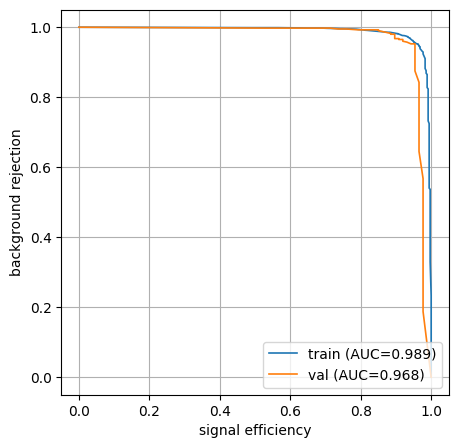

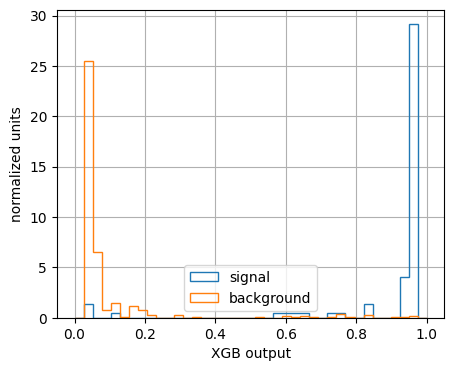

In [26]:
from sklearn.metrics import roc_curve, auc

# validation metrics and plots (mirrors tutorial style)
train_pred = bst.predict(dtrain)
val_pred = bst.predict(dval)

fpr_train, tpr_train, _ = roc_curve(y_train, train_pred) # false positive rate, true positive rate for train
fpr_val, tpr_val, _ = roc_curve(y_val, val_pred) # same but for the test

train_auc = auc(fpr_train, tpr_train) # auc = area under ROC -> measures ability to distinguish classes
val_auc = auc(fpr_val, tpr_val)

print(f"train AUC: {train_auc:.3f}")
print(f"validation AUC: {val_auc:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(tpr_train, 1 - fpr_train, lw=1.2, label=f"train (AUC={train_auc:.3f})") # 1 - fpr to give background rejection
ax.plot(tpr_val, 1 - fpr_val, lw=1.2, label=f"val (AUC={val_auc:.3f})")
ax.set_xlabel("signal efficiency")
ax.set_ylabel("background rejection")
ax.grid(True)
ax.legend(loc="lower right")
plt.show()

# score distributions for sanity check
bins = np.linspace(0, 1, 40)
sig_scores = val_pred[y_val == 1]
bkg_scores = val_pred[y_val == 0]
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(sig_scores, bins=bins, histtype="step", density=True, label="signal")
ax.hist(bkg_scores, bins=bins, histtype="step", density=True, label="background")
ax.set_xlabel("XGB output")
ax.set_ylabel("normalized units")
ax.legend()
ax.grid(True)
plt.show()

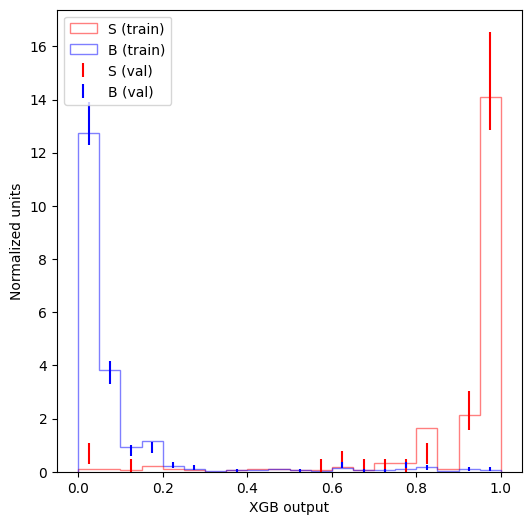

In [25]:
def compare_train_test(model, X_train, y_train, X_test, y_test, bins=20):
    decisions = []
    for X, y in ((X_train, y_train), (X_test, y_test)):
        scores = model.predict(xgb.DMatrix(X))
        d1 = scores[y > 0.5].ravel()
        d2 = scores[y < 0.5].ravel()
        decisions += [d1, d2]

    plt.subplots(figsize=(6, 6))
    plt.hist(decisions[0],
             color="r", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="S (train)")
    plt.hist(decisions[1],
             color="b", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="B (train)")

    hist, bins = np.histogram(decisions[2], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    plt.errorbar(center, hist, yerr=err, fmt="none", c="r", label="S (val)")

    hist, bins = np.histogram(decisions[3], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[3]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    plt.errorbar(center, hist, yerr=err, fmt="none", c="b", label="B (val)")

    plt.xlabel("XGB output")
    plt.ylabel("Normalized units")
    plt.legend(loc="best")
    plt.savefig("Xgboutput.png", bbox_inches="tight")

compare_train_test(bst, X_train, y_train, X_val, y_val)